# Tutorial 1: Integrating adjacent DLPFC slices
This tutorial demonstrates STAligner's ablility to integrate multiple adjacent slices. The slices are sampled from human dorsolateral prefrontal cortex (DLPFC) and the processed data can be downloaded from https://drive.google.com/drive/folders/1pHJy2cB9BKqc3ny9IpvVhiw_8ukJMzPW?usp=share_link.

## Preparation

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
# import ST_utils
# import train_STAligner
import STAligner

# the location of R (used for the mclust clustering)
import os
#os.environ['R_HOME'] = "/home/xzhou/anaconda3/envs/PyG/lib/R"
#os.environ['R_USER'] = "/home/xzhou/anaconda3/envs/PyG/lib/python3.8/site-packages/rpy2"
import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri


import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg
from pathlib import Path

import torch
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Load Data

In [10]:
ROOT_PATH = Path('../../../data/MBA-MBP')
DATA_NAME = 'Mouse_Brain_Anterior'
adata_anterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_anterior.var_names_make_unique()

spatial_a=pd.read_csv("../../../data/MBA-MBP/Mouse_Brain_Anterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_anterior.obs["x_array"]=spatial_a[2]
adata_anterior.obs["y_array"]=spatial_a[3]
adata_anterior.obs["x_pixel"]=spatial_a[4]
adata_anterior.obs["y_pixel"]=spatial_a[5]
adata_anterior.obs['boundary'] = 0
# adata_anterior.obs['x_pixel'] = adata_anterior.obsm['spatial'][:,0]
# adata_anterior.obs['y_pixel'] = adata_anterior.obsm['spatial'][:,1]
# make spot name unique
adata_anterior.obs_names = [x + '_anterior' for x in adata_anterior.obs_names]

# adata_anterior.layers['count'] = adata_anterior.X.toarray()
# sc.pp.normalize_total(adata_anterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_anterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable'] == True]
# sc.pp.scale(adata_anterior)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable']]
adata_anterior

AnnData object with n_obs × n_vars = 2695 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [11]:
DATA_NAME = 'Mouse_Brain_Posterior'
adata_posterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_posterior.var_names_make_unique()

spatial_p=pd.read_csv("../../../data/MBA-MBP/Mouse_Brain_Posterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_posterior.obs["x_array"]=spatial_p[2]
adata_posterior.obs["y_array"]=spatial_p[3]
adata_posterior.obs["x_pixel"]=spatial_p[4]
adata_posterior.obs["y_pixel"]=spatial_p[5]
adata_posterior.obs['boundary'] = 0
# adata_posterior.obs['x_pixel'] = adata_posterior.obsm['spatial'][:,0]
# adata_posterior.obs['y_pixel'] = adata_posterior.obsm['spatial'][:,1]
# make spot name unique
adata_posterior.obs_names = [x + '_posterior' for x in adata_posterior.obs_names]

# adata_posterior.layers['count'] = adata_posterior.X.toarray()
# sc.pp.normalize_total(adata_posterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_posterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable'] == True]
# sc.pp.scale(adata_posterior)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable']]
adata_posterior

AnnData object with n_obs × n_vars = 3355 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [12]:
obs_a = adata_anterior.obs
obs_p = adata_posterior.obs
# obs_p["x_pixel"]=obs_p["x_pixel"]-np.min(obs_p["x_pixel"])+np.min(obs_a["x_pixel"])
obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) - 150
# obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) + 1500

obs_a["boundary"] = 0
obs_p["boundary"] = 0

for i in list(set(obs_a['x_array'])):
    j = obs_a[obs_a['x_array'] == i].max()["y_array"]
    temp = obs_a[obs_a['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_a.loc[temp, "boundary"] = 1

for i in list(set(obs_p['x_array'])):
    j = obs_p[obs_p['x_array'] == i].min()["y_array"]
    temp = obs_p[obs_p['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_p.loc[temp, "boundary"] = 1

mean_a_y = obs_a[obs_a["boundary"] == 1]['x_pixel'].mean()
mean_p_y = obs_p[obs_p["boundary"] == 1]['x_pixel'].mean()
obs_p['x_pixel'] = obs_p['x_pixel'] + mean_a_y - mean_p_y

In [13]:
adata_anterior.obsm["spatial_aligned"] = adata_anterior.obs.loc[adata_anterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()
adata_posterior.obsm["spatial_aligned"] = adata_posterior.obs.loc[adata_posterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()

In [14]:
list_adata = [adata_anterior, adata_posterior]

In [15]:
import anndata as ad
pre_adata = ad.concat(list_adata, label="batch_name", keys=['anterior', 'posterior'])
pre_adata.obs["batch_name"] = pre_adata.obs["batch_name"].astype('category')
pre_adata

AnnData object with n_obs × n_vars = 6050 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name'
    obsm: 'spatial', 'spatial_aligned'

In [16]:
pre_adata.obs['batch_name']

AAACAAGTATCTCCCA-1_anterior      anterior
AAACACCAATAACTGC-1_anterior      anterior
AAACAGAGCGACTCCT-1_anterior      anterior
AAACAGCTTTCAGAAG-1_anterior      anterior
AAACAGGGTCTATATT-1_anterior      anterior
                                  ...    
TTGTTCAGTGTGCTAC-1_posterior    posterior
TTGTTGTGTGTCAAGA-1_posterior    posterior
TTGTTTCACATCCAGG-1_posterior    posterior
TTGTTTCATTAGTCTA-1_posterior    posterior
TTGTTTCCATACAACT-1_posterior    posterior
Name: batch_name, Length: 6050, dtype: category
Categories (2, object): ['anterior', 'posterior']

In [17]:
slice_name_list = list(pre_adata.obs['batch_name'].unique())
slice_name_list

['anterior', 'posterior']

In [18]:
Batch_list = []
adj_list = []
# section_ids = ['Mouse_Brain_Anterior','Mouse_Brain_Posterior']
# print(section_ids)

for i, section_id in enumerate(slice_name_list):
    # print(section_id)
    # input_dir = os.path.join('../../../data/MBA-MBP', section_id)
    # adata = sc.read_visium(path=input_dir, count_file=section_id + '_filtered_feature_bc_matrix.h5', load_images=True)
    # adata.var_names_make_unique(join="++")

    # read the annotation
    # Ann_df = pd.read_csv(os.path.join(input_dir, 'manual_annotations.txt'), sep='\t', header=None, index_col=0)
    # Ann_df.columns = ['Ground Truth']
    # Ann_df[Ann_df.isna()] = "unknown"
    # adata.obs['Ground Truth'] = Ann_df.loc[adata.obs_names, 'Ground Truth'].astype('category')
    
    # make spot name unique
    # adata.obs_names = [x+'_'+section_id for x in adata.obs_names]
    
    adata_tmp = pre_adata[pre_adata.obs['batch_name'] == slice_name_list[i]]
    
    
    # Constructing the spatial network
    STAligner.Cal_Spatial_Net(adata_tmp, rad_cutoff=250) # the spatial network are saved in adata.uns[‘adj’]
    # STAligner.Stats_Spatial_Net(adata) # plot the number of spatial neighbors
    
    # Normalization
    sc.pp.highly_variable_genes(adata_tmp, flavor="seurat_v3", n_top_genes=5000)
    sc.pp.normalize_total(adata_tmp, target_sum=1e4)
    sc.pp.log1p(adata_tmp)
    adata_tmp = adata_tmp[:, adata_tmp.var['highly_variable']]

    adj_list.append(adata_tmp.uns['adj'])
    Batch_list.append(adata_tmp)

------Calculating spatial graph...
The graph contains 31002 edges, 2695 cells.
11.5035 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 38870 edges, 3355 cells.
11.5857 neighbors per cell on average.


## Concat the scanpy objects for multiple slices

In [19]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=slice_name_list)
# adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (6050, 3050)


## Concat the spatial network for multiple slices

In [20]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(slice_name_list)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

## Running STAligner

In [21]:
%%time
adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh = 50, device=used_device)

STAligner(
  (conv1): GATConv(3050, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 3050, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [00:05<00:00, 99.70it/s] 


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


100%|██████████| 500/500 [00:05<00:00, 84.84it/s]

CPU times: total: 10.8 s
Wall time: 11.2 s


## Clustering

In [22]:
STAligner.ST_utils.mclust_R(adata_concat, num_cluster=32, used_obsm='STAligner')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 6050 × 3050
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name', 'slice_name', 'mclust'
    uns: 'edgeList'
    obsm: 'spatial', 'spatial_aligned', 'STAGATE', 'STAligner'

In [28]:
adata1 = adata_concat[adata_concat.obs['batch_name'] == 'anterior']
# sc.pl.spatial(adata1, img_key=None, color=['mclust'], title=[''],
#               legend_loc=None, legend_fontsize=12, show=False, frameon=False,
#               spot_size=100)

In [39]:
df_label = pd.read_csv('../../../data/MBA-MBP/' + 'Mouse_Brain_Anterior/' + 'manual_annotations.tsv', sep='\t',  index_col=0)
#转换index名称
index = [s + '_anterior' for s in df_label.index]
df_label.index = index
adata1.obs["layer_guess"] = df_label['ground_truth']

In [40]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from my6_Triplet.utils import compute_PAS, compute_CHAOS

In [41]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
ARI = ari_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total ARI:{ARI}")

total ARI:0.41576607361537515


In [42]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
NMI = nmi_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total AMI:{AMI}")
ACC = 1/2 * (NMI + AMI)
print(f"total ACC:{ACC}")

total NMI:0.6790310363603455
total AMI:0.6561795939081493
total ACC:0.6676053151342474


In [43]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
HOM = hom_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total COM:{COM}")
V = 2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total HOM:0.6184526762976129
total COM:0.752765541458244
total V:0.6790310363603455


In [44]:
from my6_Triplet.utils import calculate_scs 

scs1 = calculate_scs(adata1.obsm['spatial'], adata1.obs['mclust'], n_neighbors=10)
scs1

0.7902782931354358

[<Axes: xlabel='spatial1', ylabel='spatial2'>]

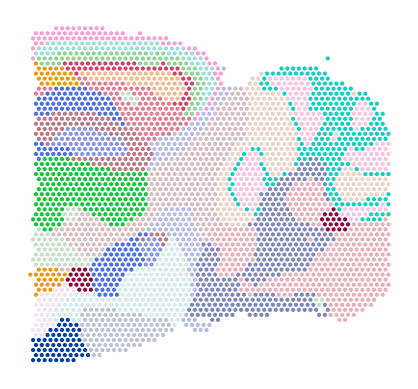

In [46]:
adata2 = adata_concat[adata_concat.obs['batch_name'] == 'posterior']
sc.pl.spatial(adata2, img_key=None, color=['mclust'], title=[''],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=100)

In [47]:
scs2 = calculate_scs(adata2.obsm['spatial'], adata2.obs['mclust'], n_neighbors=10)
scs2

0.7888524590163934

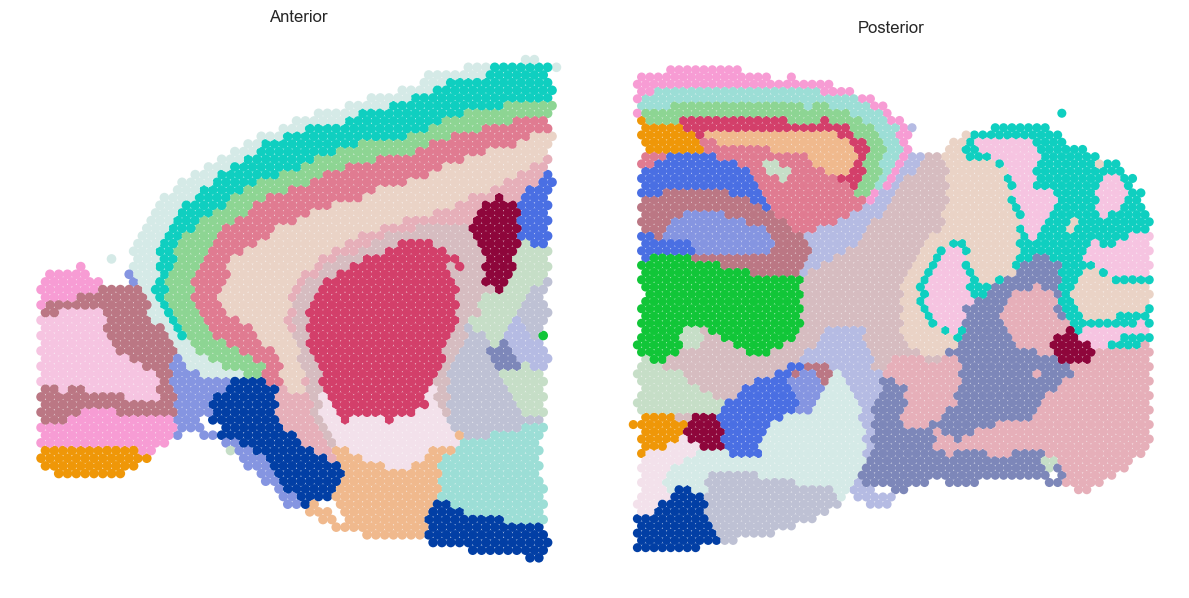

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 绘制第一个批次的空间图
sc.pl.spatial(adata1, ax=axes[0], img_key=None, color=['mclust'], title=['Anterior'],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=150)

# 绘制第二个批次的空间图
sc.pl.spatial(adata2, ax=axes[1], img_key=None, color=['mclust'], title=['Posterior'],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=150)

# 显示图像
plt.tight_layout()
plt.show()

In [50]:
adata_concat

AnnData object with n_obs × n_vars = 6050 × 3050
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name', 'slice_name', 'mclust'
    uns: 'edgeList'
    obsm: 'spatial', 'spatial_aligned', 'STAGATE', 'STAligner'

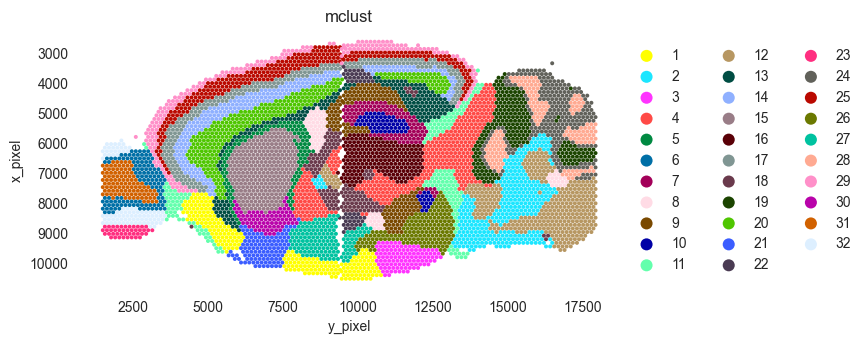

In [53]:
import matplotlib.pyplot as plt

plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

# 过滤掉 'mclust' 为 NaN 的数据
subadata = adata_concat[~adata_concat.obs['mclust'].isna()]
ax=sc.pl.scatter(subadata,alpha=1,x="y_pixel",y="x_pixel",color="mclust",show=False,size=200000/adata_concat.shape[0])
ax.set_aspect('equal', 'box')
ax.axes.invert_yaxis()
plt.grid(False)

1.0536669899859685


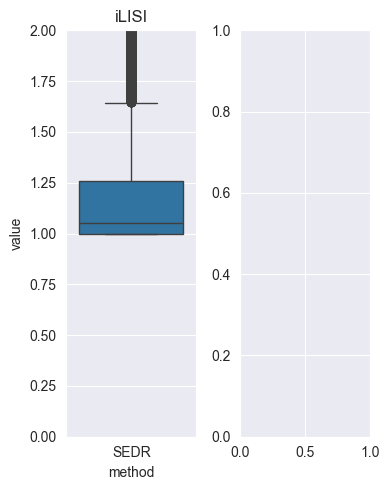

In [19]:
import seaborn as sns
import harmonypy as hm

iLISI = hm.compute_lisi(adata_concat.obsm['STAligner'], adata_concat.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
# cLISI = hm.compute_lisi(adata.obsm['SEDR'], adata.obs[['layer_guess']], label_colnames=['layer_guess'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

# df_cLISI = pd.DataFrame({
#     'method': 'SEDR',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
# sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(0, 2)
# axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
# axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
# print(np.median(cLISI))